In [9]:
#VaR tests and vizualization
from scipy.stats import *
from scipy import stats 
from typing import Union, List, Literal, TypeAlias
import numpy as np
import numpy.typing as npt
import pandas as pd
from functools import wraps, partial
from arch import arch_model
import matplotlib.pyplot as plt 

from Vares import EVT_var, historical_var, parametric_var_normal
import Vares

In [10]:
_ = pd.read_excel('hist.xlsx').to_numpy()
prices_usd = _[:, -2]

def return_array(prices): 
    rets = np.diff(prices) / prices[:-1]
    rets = np.array(rets, dtype='float64')
    return rets 

original_returns_usd  = return_array(prices_usd)
original_returns_usd_scaled = original_returns_usd * 100

log_returns_usd = np.log(1 + original_returns_usd)
log_returns_usd_scaled = log_returns_usd * 100 

# Rolling parameters
window = 365 #calendar year 
alpha = 0.01  

rolling_mean = np.convolve(log_returns_usd_scaled, np.ones(window)/window, mode='valid')

In [44]:
import pickle

with open('prices_usd.pkl', 'wb') as f: 
    pickle.dump(prices_usd, f)

with open('original_returns_usd.pkl', 'wb') as f: 
    pickle.dump(original_returns_usd, f)

with open('log_returns_usd.pkl', 'wb') as f: 
    pickle.dump(log_returns_usd, f)

In [11]:
Vares.ENABLE_TIMING = False

In [12]:
EVT_var(original_returns_usd_scaled[1000:1365])

IMPORTANT 18 365 0.750240855460267 0.2417556084228047 0


Array(2.58019452, dtype=float64)

In [13]:
#simple 1 day VaR 
lag = 365 #calendar year
time_series_length = original_returns_usd.shape[0]
avialable_lenth = time_series_length - lag

historical_vars_99 = [0]*lag
parametric_vars_99 = [0]*lag
EVT_vars_99 = [0]*lag
historical_vars_95 = [0]*lag
parametric_vars_95 = [0]*lag
EVT_vars_95 = [0]*lag

for t in range(avialable_lenth): 
    returns_sliced = log_returns_usd_scaled[t:t+365]
    historical_vars_99.append(historical_var(returns_sliced, alpha=0.01))
    historical_vars_95.append(historical_var(returns_sliced, alpha=0.05))
    parametric_vars_99.append(parametric_var_normal(returns_sliced, alpha=0.01))
    parametric_vars_95.append(parametric_var_normal(returns_sliced, alpha=0.05))
    # EVT_vars_99.append(EVT_var(returns_sliced, alpha=0.01))
    # EVT_vars_95.append(EVT_var(returns_sliced, alpha=0.05))


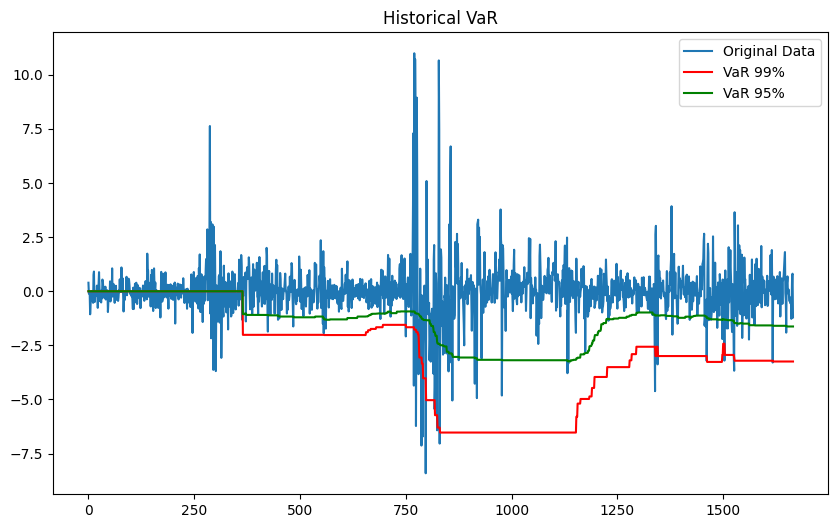

In [14]:
historical_vars_99_ = [-1 * _ for _ in historical_vars_99]
historical_vars_95_ = [-1 * _ for _ in historical_vars_95]

# Plot original data and fitted values
plt.figure(figsize=(10, 6))
plt.plot(log_returns_usd_scaled, label='Original Data')
plt.plot(historical_vars_99_, color='red', label='VaR 99%')
plt.plot(historical_vars_95_, color='green', label='VaR 95%')
plt.title('Historical VaR')
plt.legend()
plt.show()


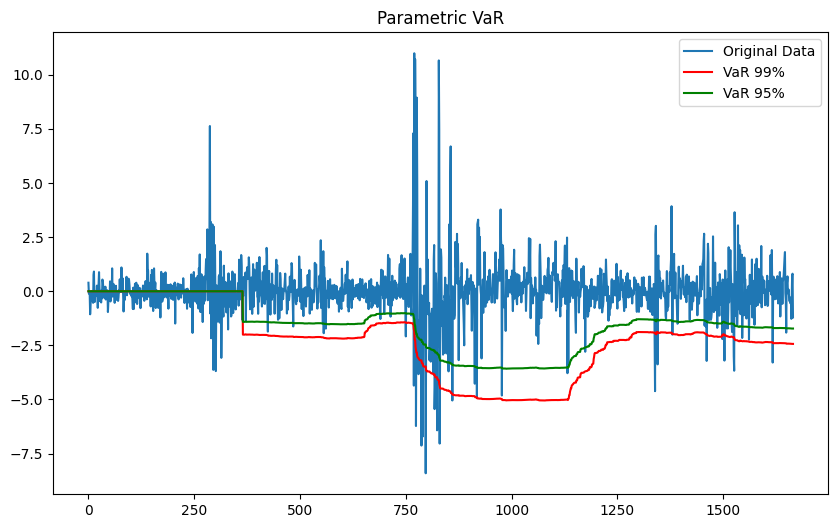

In [15]:
parametric_vars_99_ = [-1 * _ for _ in parametric_vars_99]
parametric_vars_95_ = [-1 * _ for _ in parametric_vars_95]

# Plot original data and fitted values
plt.figure(figsize=(10, 6))
plt.plot(log_returns_usd_scaled, label='Original Data')
plt.plot(parametric_vars_99_, color='red', label='VaR 99%')
plt.plot(parametric_vars_95_, color='green', label='VaR 95%')
plt.title('Parametric VaR')
plt.legend()
plt.show()

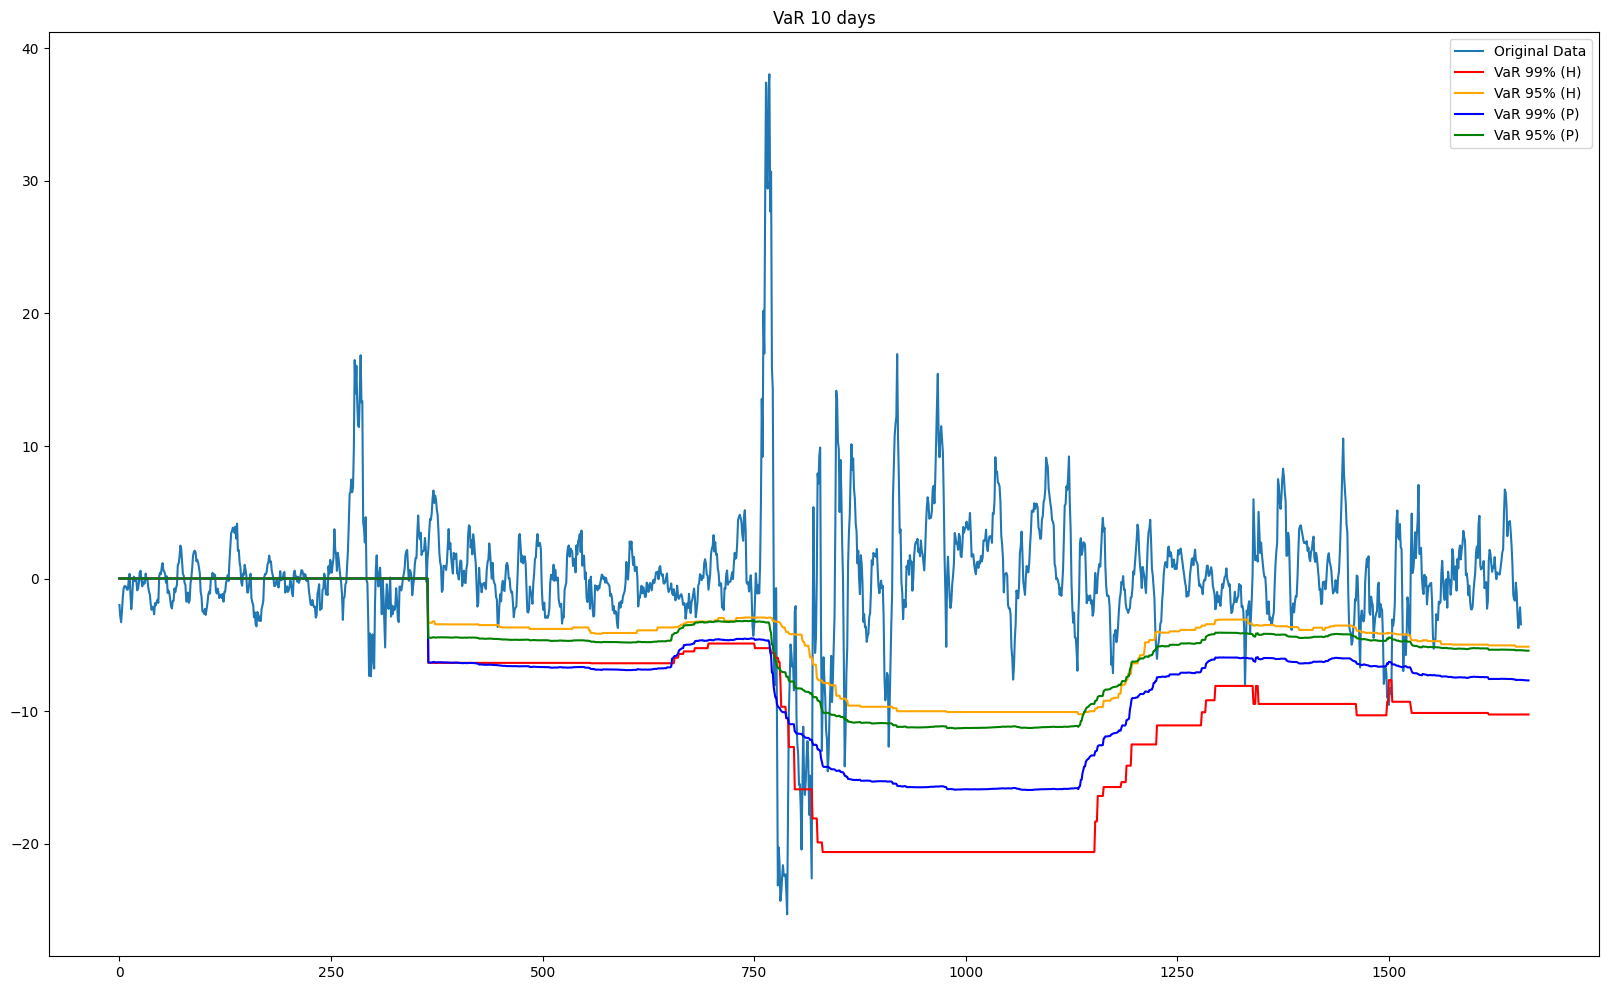

In [17]:
window = 10
cummulative_log_returns = np.convolve(log_returns_usd_scaled, np.ones(window), mode='valid')

historical_vars_99_10 = [-1 * _ * np.sqrt(10) for _ in historical_vars_99]
historical_vars_95_10 = [-1 * _ * np.sqrt(10) for _ in historical_vars_95]

parametric_vars_99_10 = [-1 * _ * np.sqrt(10) for _ in parametric_vars_99]
parametric_vars_95_10 = [-1 * _ * np.sqrt(10) for _ in parametric_vars_95]

# Plot original data and fitted values
plt.figure(figsize=(20, 12))
plt.plot(cummulative_log_returns, label='Original Data')
plt.plot(historical_vars_99_10, color='red', label='VaR 99% (H)')
plt.plot(historical_vars_95_10, color='orange', label='VaR 95% (H)')
plt.plot(parametric_vars_99_10, color='blue', label='VaR 99% (P)')
plt.plot(parametric_vars_95_10, color='green', label='VaR 95% (P)')
plt.title('VaR 10 days')
plt.legend()
plt.show()


GARCH's

In [18]:
import sys 

import Vares_simulations    

if Vares_simulations in sys.modules: 
    del sys.modules[Vares_simulations]

from Vares_simulations import _terminal_returns, solve_local_vol_gbm, solve_simple_gbm, __DISTRIBUTIONS__
from Vares_simulations import * 

In [19]:
import inspect 

print(inspect.getsource(solve_local_vol_gbm))

@Auxiliary.timer
def solve_local_vol_gbm(
        params: GBMParams, 
        T: int,
        n_paths: int = 5000,
        S_0: float = 1): 
    '''Same as solve_simple_gbm(), but allows for varying daily volatility of the underlying. A more flexible solution'''
    
    if T < params.volatility.shape[0]: 
        raise ValueError('Quantity of forecasted volatility can not exceed number of days to simulte')
    elif T > params.volatility.shape[0]:
        print('Number of simulated days exceed number of forecasted volality points. Simulation will assume constant long-term volatility.')

    W_t = stats.norm.rvs(scale=1, size=(n_paths, T))
    d_log_S = np.zeros(shape=(n_paths, T))
    #infering daily price 
    for t in range(params.volatility.shape[0]): 
        d_log_S[:, t:t+1] = ((params.mean - ((params.volatility[t]**2) / 2)) 
                + params.volatility[t] * W_t[:, t:t+1])
    if T > params.volatility.shape[0]: 
        _ = params.volatility.shape[0] 
        d_log_S[:, _

In [20]:
def make_random_path_simulator_local_vol_log(
        params: SimParams,
        T: int, 
        dist: distributions = 't',
        granularity: int = 1000,
        **kwargs
    ): 
    '''Simulates returns driven by the prespecified innovation (dist). Kwargs allow for adjusting parameters of particular distributions.
    Returns a batch of simulated data. The simulated data is shifted by -1 term.'''

    if T < params.volatility.shape[0]: 
        raise ValueError('Quantity of forecasted volatility can not exceed number of days to simulte')
    
    elif T > params.volatility.shape[0]:
        print('Number of simulated days exceed number of forecasted volality points. Simulation will assume constant long-term volatility.')

    def simulate(n_paths: int, seed = None):
        if seed is not None:
            rng = np.random.default_rng(seed=seed)
        else:
            rng = np.random.default_rng()

        time_grid = T * granularity
        dt = 1 / granularity
        stoch_comp = __DISTRIBUTIONS__[dist].rvs(**kwargs, size=(n_paths, time_grid))

        #iterating through available volatility points 
        d_log_S = np.zeros(shape=(n_paths, time_grid))
        for t in range(params.volatility.shape[0]):
            _t = t * granularity
            d_log_S[:, _t:_t+granularity] = (
                params.mean * dt + 
                params.volatility[t] * stoch_comp[:, _t:_t+granularity] * np.sqrt(dt)
            )
        _T = params.volatility.shape[0] * granularity
        d_log_S[:, _T:] = ((params.mean * dt) +
                    params.volatility[-1] * stoch_comp[:, _T:] * np.sqrt(dt))

        cum_log_returns = np.cumsum(d_log_S, axis=-1)
        return cum_log_returns
        # cum_returns = np.exp(cum_log_returns) - 1

        # return cum_returns
    return simulate 

In [21]:
p_usd = ProtoPortfolio(log_returns_usd) 
p_usd.calibrate(horizon=10)
params_usd = SimParams(p_usd.parameters.volatility, p_usd.parameters.mean)

simulator_usd_norm = make_random_path_simulator_local_vol_log(params_usd, 10, dist='norm')
returns_usd_sim_norm = _terminal_returns(simulator_usd_norm, 50000)
# simulator_usd_t = make_random_path_simulator_local_vol_log(params_usd, 10, df=3, scale=0.55)
# returns_usd_sim_t = _terminal_returns(simulator_usd_t, 50000)

d:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\arch\univariate\base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0001599. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(


In [22]:
_ = np.sort(returns_usd_sim_norm)
_[:500]

array([-0.12321047, -0.12301144, -0.11862544, -0.11475185, -0.11332907,
       -0.10897466, -0.10725704, -0.10707582, -0.10631419, -0.10622085,
       -0.10576261, -0.10448005, -0.10268701, -0.1026147 , -0.10188056,
       -0.10172619, -0.10138157, -0.10088183, -0.10082187, -0.10063251,
       -0.10056204, -0.10051301, -0.10011358, -0.10004608, -0.09984823,
       -0.09922989, -0.09866295, -0.09788631, -0.09749764, -0.09735152,
       -0.09698266, -0.09697238, -0.09673943, -0.09664377, -0.09656524,
       -0.09645092, -0.09553517, -0.09543935, -0.09521944, -0.09453675,
       -0.09442994, -0.09419605, -0.09409673, -0.09374678, -0.09344179,
       -0.09316744, -0.09309422, -0.09267047, -0.09258692, -0.09214839,
       -0.09211045, -0.0920703 , -0.09188956, -0.09146618, -0.09143877,
       -0.09138081, -0.09129699, -0.091272  , -0.09094607, -0.09080625,
       -0.09071262, -0.0901609 , -0.0901277 , -0.09012332, -0.09009552,
       -0.09004617, -0.09003008, -0.08993682, -0.08989501, -0.08

Tests 

In [ ]:
#1 analytical vs simulation 
#2 slice fitting
#3 garch fitting 
martingale_params = params_usd
martingale_params.mean = 0.0

s_0 = log_returns_usd[0]
returns_usd_ana = solve_local_vol_gbm(params_usd, 10, 500000)

_ = np.sort(returns_usd_ana)
_[5000]

np.float64(-0.06667208104886624)

In [ ]:
#outputs just the log_values
simulator_usd_norm = make_random_path_simulator_local_vol_log(martingale_params, 10, dist='norm', granularity=100) 
returns_usd_sim_norm = _terminal_returns(simulator_usd_norm, 50000)

_ = np.sort(returns_usd_sim_norm)
np.exp(_[500]) - 1

np.float64(-0.06669708493101834)

VaR GARCH 

In [23]:
def solve_local_vol_gbm_2(
        params: GBMParams, 
        T: int,
        n_paths: int = 5000): 
    '''Same as solve_simple_gbm(), but allows for varying daily volatility of the underlying. A more flexible solution'''
    
    if T < params.volatility.shape[0]: 
        raise ValueError('Quantity of forecasted volatility can not exceed number of days to simulte')
    elif T > params.volatility.shape[0]:
        print('Number of simulated days exceed number of forecasted volality points. Simulation will assume constant long-term volatility.')

    W_t = stats.norm.rvs(scale=1, size=(n_paths, T))
    d_log_S = np.zeros(shape=(n_paths, T))
    #infering daily price 
    for t in range(params.volatility.shape[0]): 
        d_log_S[:, t:t+1] = ((params.mean - ((params.volatility[t]**2) / 2)) 
                + params.volatility[t] * W_t[:, t:t+1])
    if T > params.volatility.shape[0]: 
        _ = params.volatility.shape[0] 
        d_log_S[:, _:] = ((params.mean - ((params.volatility[-1]**2) / 2)) * (T - _)
                    + params.volatility[-1] * W_t[:, _:])
    return np.sum(d_log_S, axis=1)

In [24]:
def egarch_simulation(returns, horizon=10, n_paths=500_000, granulariy=1, alpha=0.01): 
    egarch_model = arch_model(returns, vol='EGARCH', p=1, o=0, q=1)
    results_egarch = egarch_model.fit(disp='off')
    forecast = results_egarch.forecast(horizon=horizon)
    mu = results_egarch.params.get("mu", 0)
    sigma2 = forecast.variance.values[0]
    sigma = sigma2 ** (1/2) #garch model estimates the variance of the underlyinh sample
    parameters = GBMParams(volatility=sigma, mean=mu)   

    simulator = make_random_path_simulator_local_vol_log(parameters, horizon, dist='norm', granularity=granulariy)
    _returns = _terminal_returns(simulator, n_paths=n_paths)

    _ = historical_var(_returns, alpha=alpha)
    return _

def garch_simulation(returns, horizon=10, n_paths=50_000, alpha=0.01): 
    port = ProtoPortfolio(returns) 
    port.calibrate(horizon=horizon)
    parameters = SimParams(port.parameters.volatility, port.parameters.mean)

    _returns = solve_local_vol_gbm_2(parameters, horizon, n_paths)

    _returns_sorted = np.sort(_returns)
    _ = _returns_sorted[int(n_paths * alpha)]
    return _


In [25]:
log_returns_usd_scaled

array([ 0.39437596, -0.10664857, -0.07652529, ...,  0.74339296,
        0.81084188, -1.20755706], shape=(1666,))

In [26]:
egarch_vars_99 = [0]*lag
garch_vars_99 = [0]*lag

for t in range(avialable_lenth): 
    returns_sliced = log_returns_usd_scaled[t:t+365]
    # egarch_vars_99.append(egarch_simulation(returns_sliced))
    garch_vars_99.append(garch_simulation(returns_sliced))

In [27]:
garch_vars_99_neg = garch_vars_99 * -1

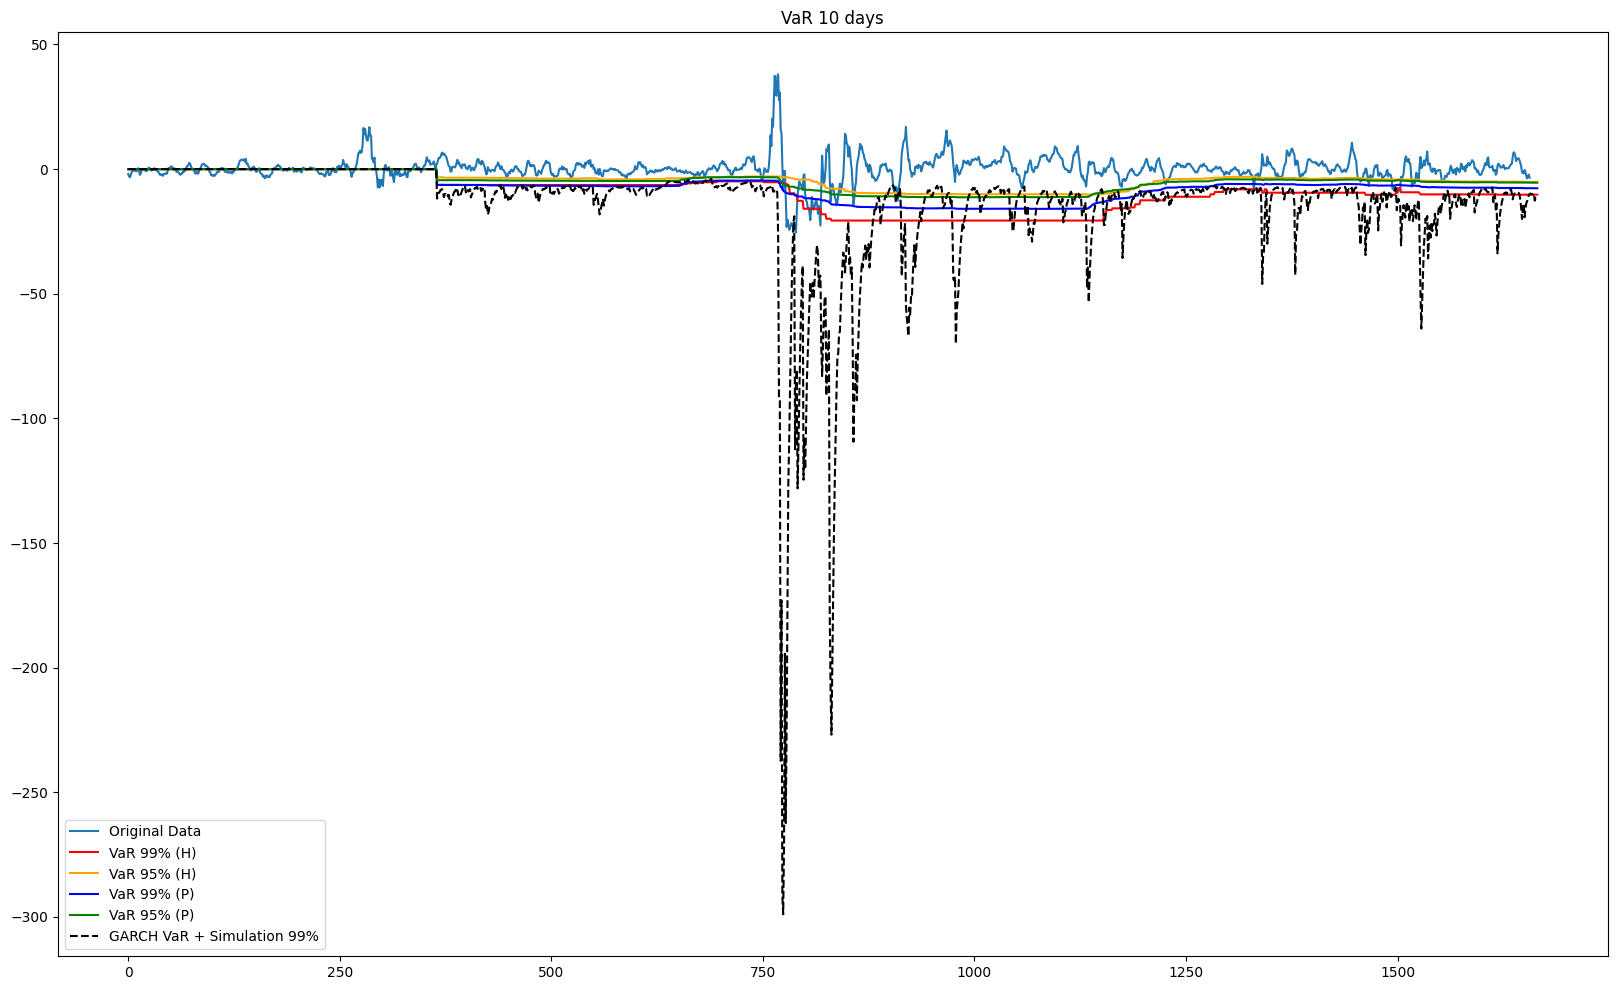

In [28]:
plt.figure(figsize=(20, 12))
plt.plot(cummulative_log_returns, label='Original Data')
plt.plot(historical_vars_99_10, color='red', label='VaR 99% (H)')
plt.plot(historical_vars_95_10, color='orange', label='VaR 95% (H)')
plt.plot(parametric_vars_99_10, color='blue', label='VaR 99% (P)')
plt.plot(parametric_vars_95_10, color='green', label='VaR 95% (P)')
plt.plot(garch_vars_99, color='black', linestyle='dashed', label='GARCH VaR + Simulation 99%')
plt.title('VaR 10 days')
plt.legend()
plt.show()

In [ ]:
with open('garch')

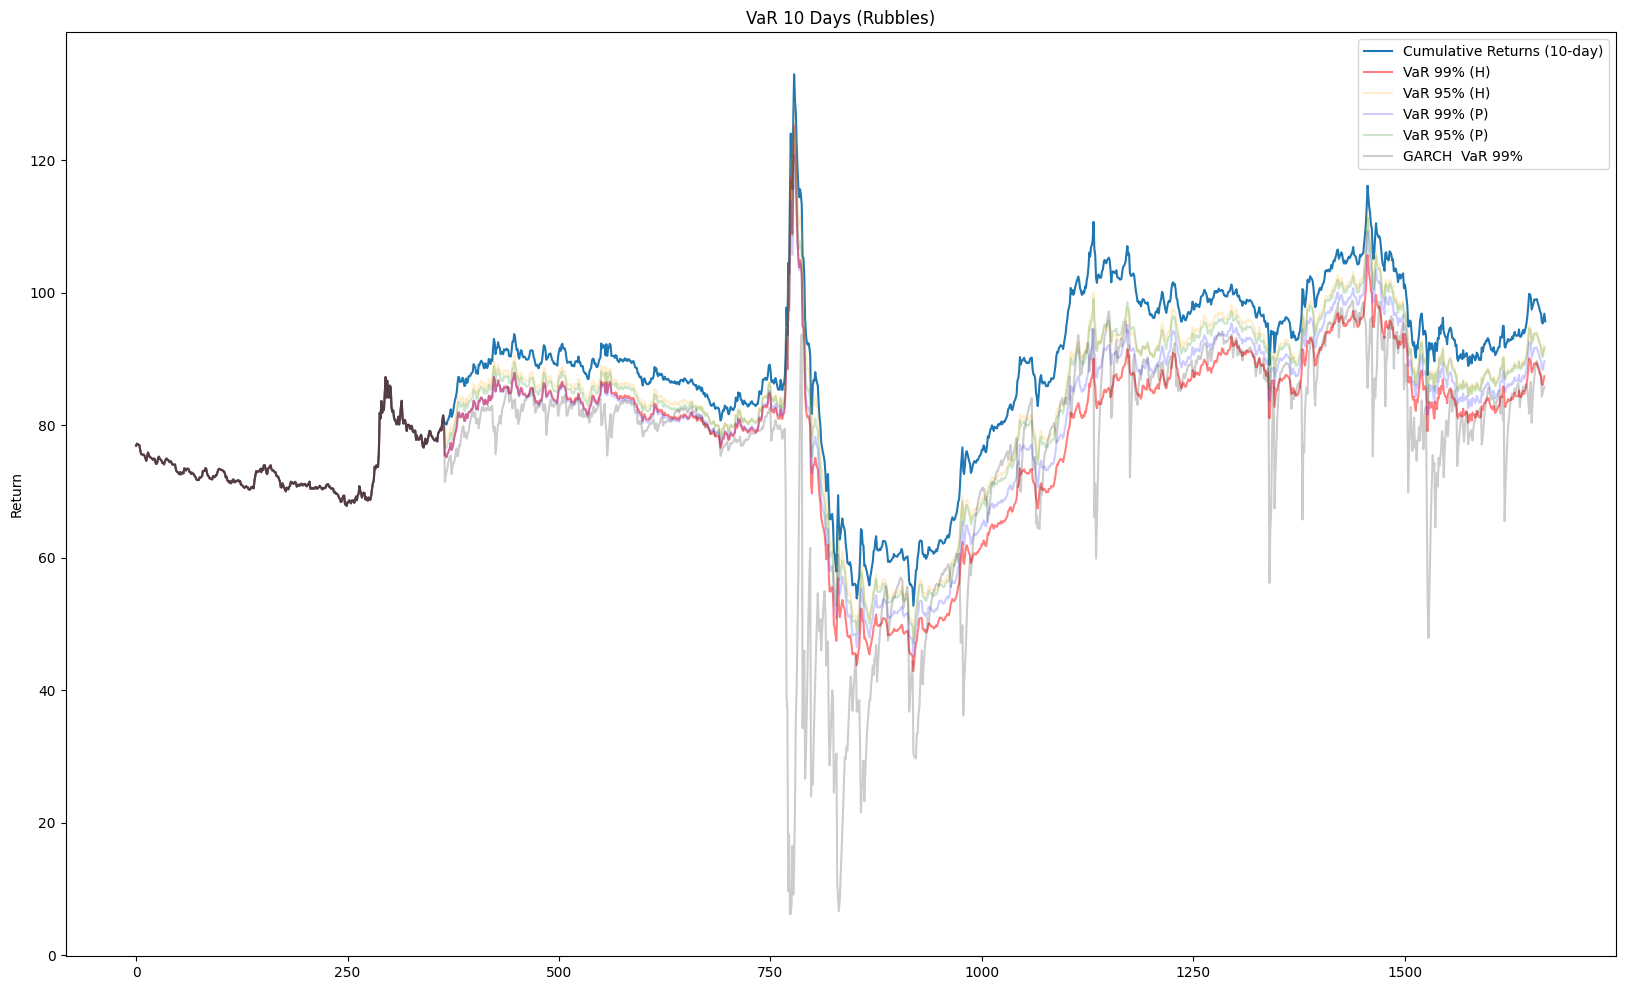

In [33]:
#VaR in rubble terms 

# Scale VaR for 10-day horizon
# Note: sqrt(T) is technically for log returns but commonly used as approximation
historical_vars_99_10 = [-1 * _ * np.sqrt(10) for _ in historical_vars_99]
historical_vars_95_10 = [-1 * _ * np.sqrt(10) for _ in historical_vars_95]
parametric_vars_99_10 = [-1 * _ * np.sqrt(10) for _ in parametric_vars_99]
parametric_vars_95_10 = [-1 * _ * np.sqrt(10) for _ in parametric_vars_95]

def turn_var_into_real_terms(var_array, prices):
    return [np.exp(log_delta / 100) * price for log_delta, price in zip(var_array, prices)]

historical_vars_real_99_10 = [np.exp(log_delta / 100) * price for log_delta, price in zip(historical_vars_99_10, prices_usd)]


# Plot with regular returns
plt.figure(figsize=(20, 12))
plt.plot(prices_usd, label='Cumulative Returns (10-day)')
plt.plot(turn_var_into_real_terms(historical_vars_99_10, prices_usd), color='red', label='VaR 99% (H)', alpha=0.5)
plt.plot(turn_var_into_real_terms(historical_vars_95_10, prices_usd), color='orange', label='VaR 95% (H)', alpha=0.2)
plt.plot(turn_var_into_real_terms(parametric_vars_99_10, prices_usd), color='blue', label='VaR 99% (P)', alpha=0.2)
plt.plot(turn_var_into_real_terms(parametric_vars_95_10, prices_usd), color='green', label='VaR 95% (P)', alpha=0.2)
plt.plot(turn_var_into_real_terms(garch_vars_99, prices_usd), color='black', label='GARCH  VaR 99%', alpha=0.2)
plt.title('VaR 10 Days (Rubbles)')
plt.ylabel('Return')
plt.legend()
plt.show()

EVT VaR

In [35]:
from Vares import MLE_EVT

def EVT_VaR_w_cutoff(returns, alpha=0.01, u_level = 0.95, return_details = False): 
    """
    EVT VaR assuming tail follow GPD (Generalized Paretto Distribution).

    For details refer to Hull, J. (2012). Risk management and financial institutions  / John C. Hull. (3rd ed.). John Wiley. Equation (12.9)
    """
    result, u, n_u = MLE_EVT(returns, u_level=u_level, mode_var=True)

    xi = result.x[0]
    _log_beta = result.x[1]
    beta = jnp.exp(_log_beta)

    nominator = beta/xi 
    power = xi * (-1)
    n = returns.shape[0]

    # print('IMPORTANT', n_u, n, beta, xi, result.status)

    VaR = u + nominator*(((n / n_u * alpha)**(power)) - 1)  
    if nominator < 0: 
        return u

    if return_details is True: 
        return VaR, result, u, [beta, xi] #allows for detailed results analysis

    return VaR 

In [36]:
EVT_VaRs = [0] * 365

for t in range(avialable_lenth): 
    returns_sliced = log_returns_usd_scaled[t:t+365]
    EVT_VaRs.append(EVT_VaR_w_cutoff(returns_sliced, alpha=0.01))

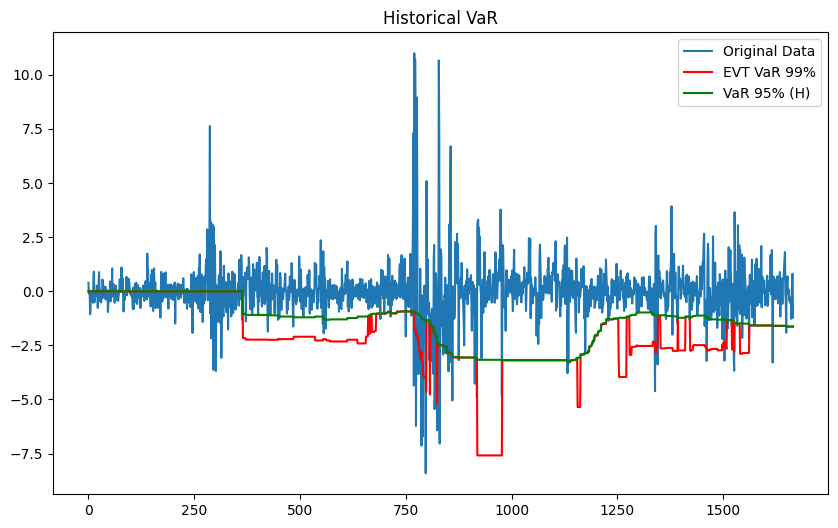

In [38]:
EVT_VaRs_neg = np.negative(EVT_VaRs)

# Plot original data and fitted values
plt.figure(figsize=(10, 6))
plt.plot(log_returns_usd_scaled, label='Original Data')
plt.plot(EVT_VaRs_neg, color='red', label='EVT VaR 99%')
plt.plot(historical_vars_95_, color='green', label='VaR 95% (H)')
plt.title('Historical VaR')
plt.legend()
plt.show()


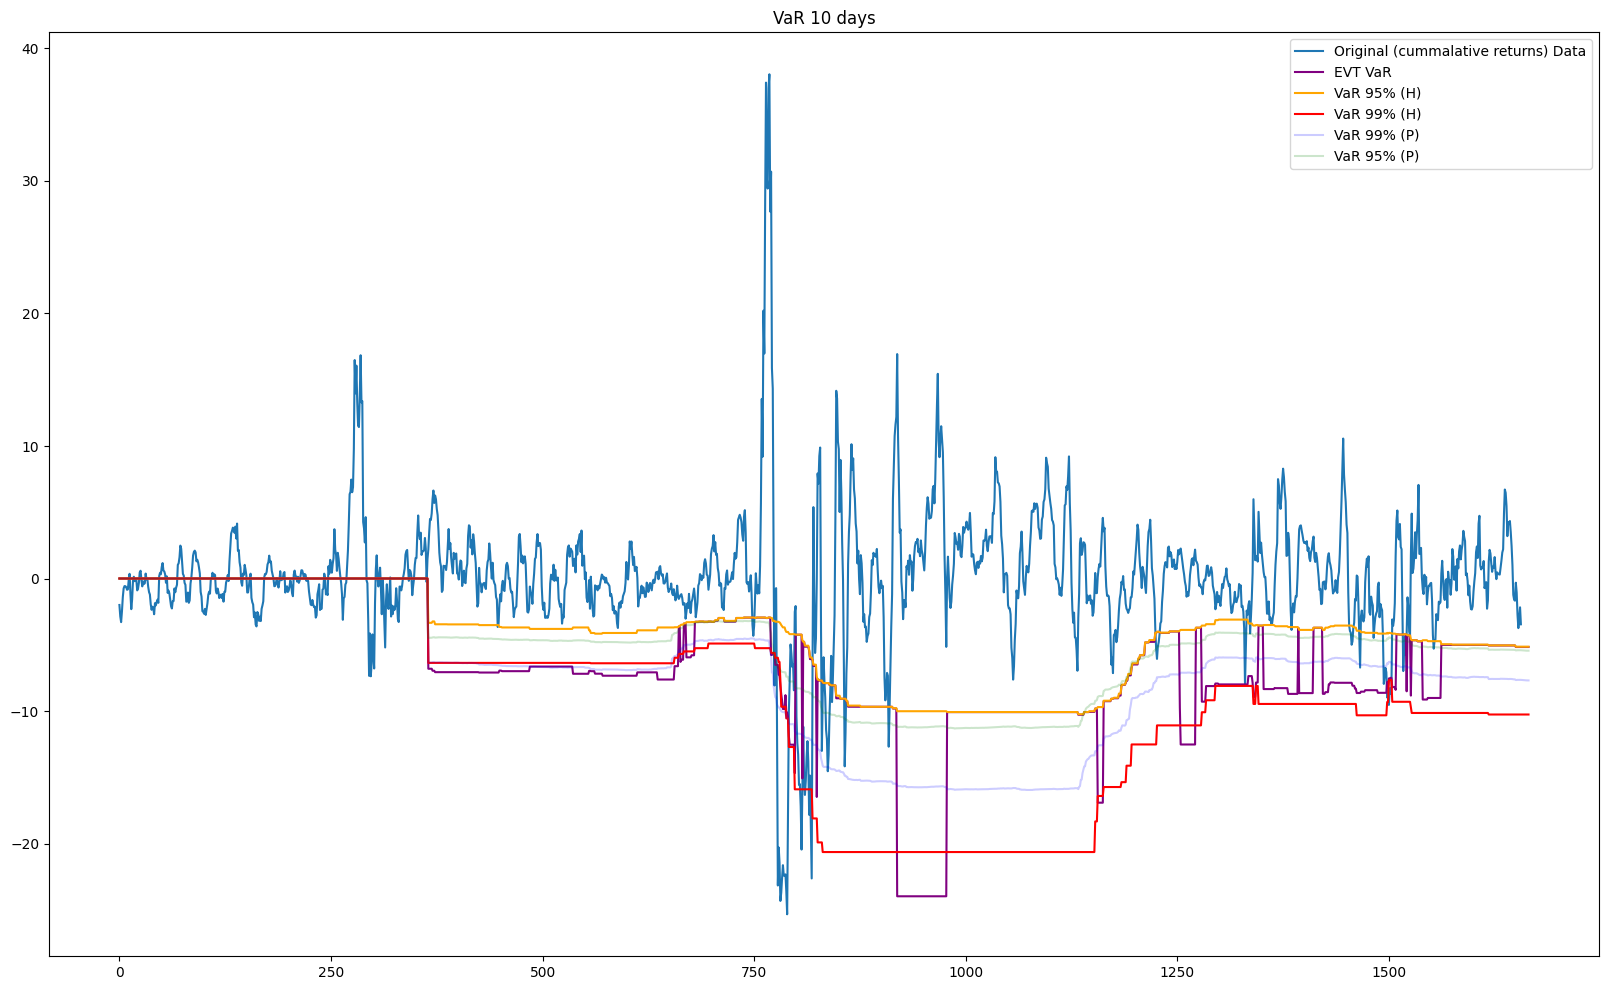

In [39]:
EVT_VaRs_neg_10 = EVT_VaRs_neg * np.sqrt(10)

plt.figure(figsize=(20, 12))
plt.plot(cummulative_log_returns, label='Original (cummalative returns) Data')
plt.plot(EVT_VaRs_neg_10, color='purple', label='EVT VaR')
plt.plot(historical_vars_95_10, color='orange', label='VaR 95% (H)')
plt.plot(historical_vars_99_10, color='red', label='VaR 99% (H)')
plt.plot(parametric_vars_99_10, color='blue', label='VaR 99% (P)', alpha=0.2)
plt.plot(parametric_vars_95_10, color='green', label='VaR 95% (P)', alpha=0.2)
plt.title('VaR 10 days')
plt.legend()
plt.show()

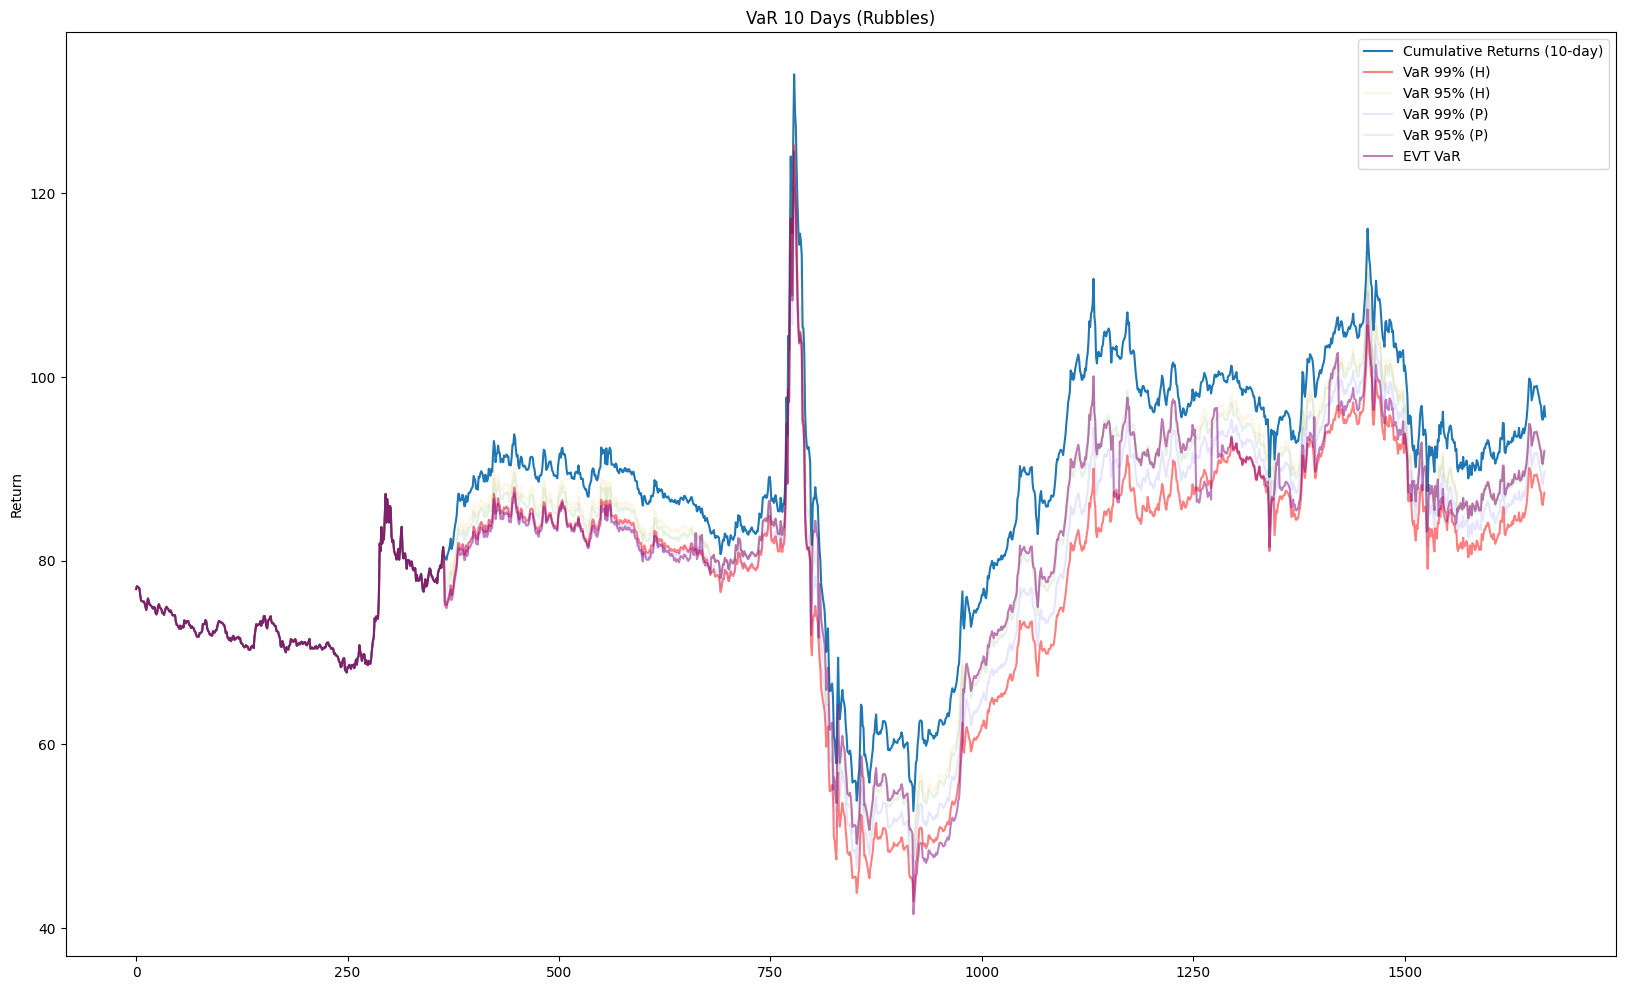

In [ ]:
# Plot with regular returns
plt.figure(figsize=(20, 12))
plt.plot(prices_usd, label='Cumulative Returns (10-day)')
plt.plot(turn_var_into_real_terms(historical_vars_99_10, prices_usd), color='red', label='VaR 99% (H)', alpha=0.5)
plt.plot(turn_var_into_real_terms(historical_vars_95_10, prices_usd), color='orange', label='VaR 95% (H)', alpha=0.1)
plt.plot(turn_var_into_real_terms(parametric_vars_99_10, prices_usd), color='blue', label='VaR 99% (P)', alpha=0.1)
plt.plot(turn_var_into_real_terms(parametric_vars_95_10, prices_usd), color='green', label='VaR 95% (P)', alpha=0.1)
plt.plot(turn_var_into_real_terms(EVT_VaRs_neg_10, prices_usd), color='purple', label='EVT VaR', alpha=0.5)
plt.title('VaR 10 Days (Rubbles)')
plt.ylabel('Return')
plt.legend()
plt.show()

GARCH assessment

Text(0.5, 1.0, 'Fitted Voltality. Garch. Horizon=1')

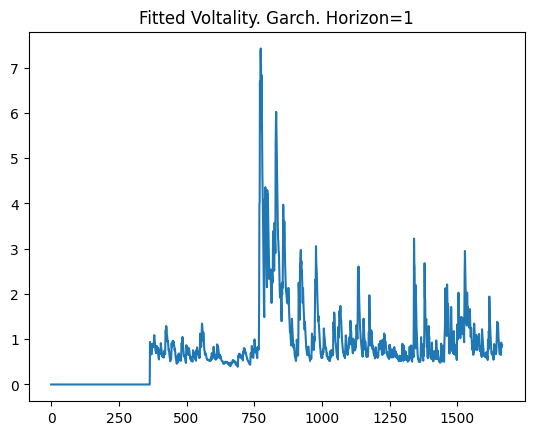

In [ ]:
poi = 820 # point of intererst
returns_slice = log_returns_usd_scaled[poi - 365: poi]

fitted_volatilities = [0] * 365

for t in range(avialable_lenth):
    returns_slice = log_returns_usd_scaled[t:t+365]
    port = ProtoPortfolio(returns_slice)
    port.calibrate(horizon=1)
    fitted_volatilities.append(port.parameters.volatility[0])

# plt.plot(fitted_volatilities, np.linspace(0, log_returns_usd_scaled.shape[0]))
plt.plot(fitted_volatilities)
plt.title('Fitted Voltality. Garch. Horizon=1')
plt.show()

4.015826944385128


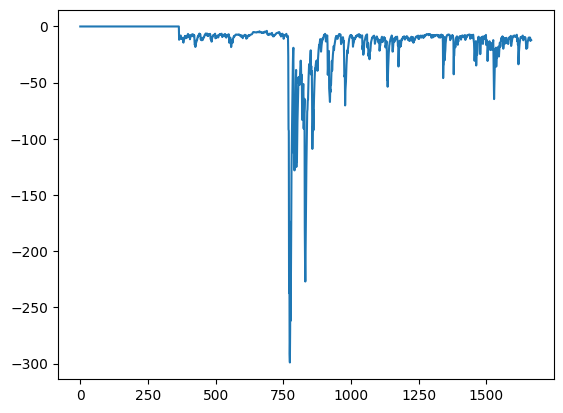

In [ ]:
plt.plot(garch_vars_99)
print(np.std(log_returns_usd_scaled[750:800]))
plt.show()

In [ ]:
def calibrate_(returns, horizon=10, **kwargs): 
        '''Private method implies variance and mean of returns of assets' returns using GARCH(p, q)
        
        Now it is unable to handle returns across multiple(>1) assets. Also can not handle horizon > 1'''
        am = arch_model(returns, vol='Garch', dist='normal', **kwargs)
        result = am.fit(disp='off')
        forecast = result.forecast(horizon=horizon)
        mu = result.params.get("mu", 0)
        sigma2 = forecast.variance.values[0]
        sigma = sigma2 ** (1/2)
        parameters = GBMParams(volatility=sigma, mean=mu)

        return parameters

def garch_simulation_2(returns, horizon=10, n_paths=50_000, alpha=0.01): 
    _  = calibrate_(returns, horizon=horizon)
    parameters = SimParams(_.volatility, _.mean)

    _returns = solve_local_vol_gbm_2(parameters, horizon, n_paths)

    _returns_sorted = np.sort(_returns)
    _ = _returns_sorted[int(n_paths * alpha)]
    return _

In [ ]:
p = calibrate_(returns_slice, horizon=10)
p

GBMParams(volatility=array([0.86884186, 0.89975973, 0.92760244, 0.95277844, 0.97562034,
       0.9964036 , 1.01535954, 1.03268479, 1.04854813, 1.06309573]), mean=np.float64(-0.008775326383024721))

In [ ]:
p = calibrate_(returns_slice, horizon=10)
p

GBMParams(volatility=array([0.86884186, 0.89975973, 0.92760244, 0.95277844, 0.97562034,
       0.9964036 , 1.01535954, 1.03268479, 1.04854813, 1.06309573]), mean=np.float64(-0.008775326383024721))

In [ ]:
def test11(returns, horizon=10, n_paths=50_000, alpha=0.01): 
    port = ProtoPortfolio(returns) 
    port.calibrate(horizon=horizon)
    parameters = SimParams(port.parameters.volatility, port.parameters.mean)

    _returns = solve_local_vol_gbm_2(parameters, horizon, n_paths)

    _returns_sorted = np.sort(_returns)
    _ = _returns_sorted[int(n_paths * alpha)]
    return _, parameters

In [ ]:
_, params1 = test11(returns_slice)
print(params1)

SimParams(volatility=array([0.86884186, 0.89975973, 0.92760244, 0.95277844, 0.97562034,
       0.9964036 , 1.01535954, 1.03268479, 1.04854813, 1.06309573]), mean=np.float64(-0.008775326383024721))


In [ ]:
import inspe

In [ ]:
garch_vars_99_second_attempt = [0]*lag

for t in range(avialable_lenth): 
    returns_sliced = log_returns_usd_scaled[t:t+365]
    # egarch_vars_99.append(egarch_simulation(returns_sliced))
    garch_vars_99_second_attempt.append(garch_simulation_2(returns_sliced, horizon=10))

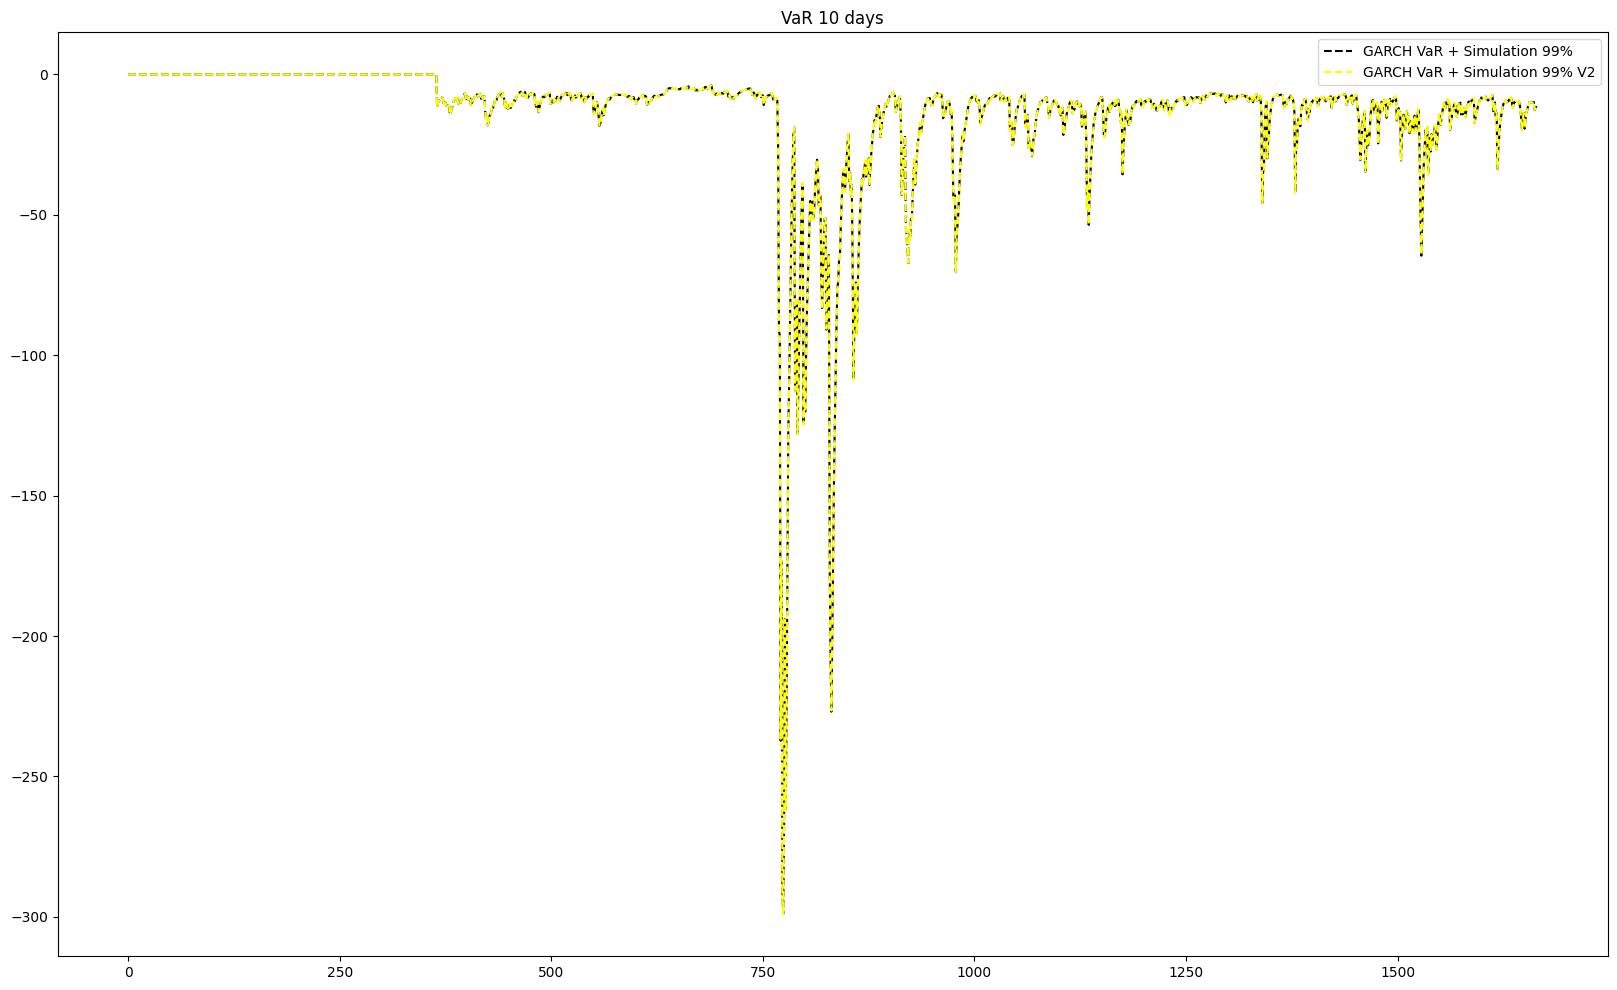

In [ ]:
plt.figure(figsize=(20, 12))
# plt.plot(cummulative_log_returns, label='Original Data')
# plt.plot(historical_vars_99_10, color='red', label='VaR 99% (H)')
# plt.plot(historical_vars_95_10, color='orange', label='VaR 95% (H)')
# plt.plot(parametric_vars_99_10, color='blue', label='VaR 99% (P)')
# plt.plot(parametric_vars_95_10, color='green', label='VaR 95% (P)')
plt.plot(garch_vars_99, color='black', linestyle='dashed', label='GARCH VaR + Simulation 99%')
plt.plot(garch_vars_99_second_attempt, color='yellow', linestyle='dashed', label='GARCH VaR + Simulation 99% V2')
plt.title('VaR 10 days')
plt.legend()
plt.show()